# Economic Growth and Poverty in Africa 

This notebook explores the relationship between economic growth, poverty, and inequality
across five African economies: **Nigeria, Ghana, Kenya, South Africa, and Ethiopia**.

The goal is not just to visualise trends but to understand the data well enough to make
informed modelling decisions. By the end of this EDA we will know:

- Which indicators are clean enough for econometric work and which are not
- Whether GDP growth translates to poverty reduction and where it fails to
- How inequality mediates the growth-poverty relationship
- What structural patterns (volatility, aid dependency, stagnation) define each country
- What the modelling notebook needs to test formally

All data is sourced from the **World Bank Open Data** via the `wbgapi` Python package.

---
## 1. Setup & Data Pull

We pull eight indicators across the five countries for the period 1990–2023. The indicator
set covers income (GDP per capita, GDP growth), welfare (poverty headcount, Gini), and
macro context (inflation, trade openness, aid flows, unemployment). This gives us both
outcome variables and potential explanatory drivers for the modelling phase.

In [1]:
import wbgapi as wb
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from pathlib import Path

PROJECT_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "environment.yml").exists()), Path.cwd())
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

INDICATORS = [
    "NY.GDP.PCAP.KD",    # GDP per capita (constant 2015 USD)
    "NY.GDP.MKTP.KD.ZG", # GDP growth (annual %)
    "SI.POV.DDAY",       # Poverty headcount ratio at $2.15/day
    "SI.POV.GINI",       # Gini index
    "NE.TRD.GNFS.ZS",   # Trade (% of GDP)
    "DT.ODA.ALLD.KD",   # Net ODA received (constant 2021 USD)
    "FP.CPI.TOTL.ZG",   # Inflation (CPI, annual %)
    "SL.UEM.TOTL.ZS",   # Unemployment (% of total labour force)
]

COUNTRIES = ["NGA", "GHA", "KEN", "ZAF", "ETH"]
LABELS = {"NGA": "Nigeria", "GHA": "Ghana", "KEN": "Kenya",
          "ZAF": "South Africa", "ETH": "Ethiopia"}

df_full = wb.data.DataFrame(
    INDICATORS,
    economy=COUNTRIES,
    time=range(1990, 2024)
)

print(f"Shape: {df_full.shape}")
print(f"Countries: {df_full.index.get_level_values('economy').unique().tolist()}")
print(f"Indicators: {df_full.index.get_level_values('series').unique().tolist()}")

Shape: (40, 34)
Countries: ['ETH', 'GHA', 'KEN', 'NGA', 'ZAF']
Indicators: ['DT.ODA.ALLD.KD', 'FP.CPI.TOTL.ZG', 'NE.TRD.GNFS.ZS', 'NY.GDP.MKTP.KD.ZG', 'NY.GDP.PCAP.KD', 'SI.POV.DDAY', 'SI.POV.GINI', 'SL.UEM.TOTL.ZS']


---
## 2. Data Coverage Audit

Before looking at any trends, we need to understand what we actually have. Survey-based
indicators like poverty and Gini are not collected annually, they depend on national
household surveys that happen every 3–7 years. If we do not audit coverage first, we
risk building models on assumptions about data that does not exist.

In [2]:
# missingness per indicator-country pair
print(df_full.isnull().sum(axis=1).to_string())

economy  series           
ETH      DT.ODA.ALLD.KD        0
         FP.CPI.TOTL.ZG        0
         NE.TRD.GNFS.ZS       21
         NY.GDP.MKTP.KD.ZG     0
         NY.GDP.PCAP.KD        0
         SI.POV.DDAY          28
         SI.POV.GINI          28
         SL.UEM.TOTL.ZS        1
GHA      DT.ODA.ALLD.KD        0
         FP.CPI.TOTL.ZG        0
         NE.TRD.GNFS.ZS        0
         NY.GDP.MKTP.KD.ZG     0
         NY.GDP.PCAP.KD        0
         SI.POV.DDAY          29
         SI.POV.GINI          29
         SL.UEM.TOTL.ZS        1
KEN      DT.ODA.ALLD.KD        0
         FP.CPI.TOTL.ZG        0
         NE.TRD.GNFS.ZS        0
         NY.GDP.MKTP.KD.ZG     0
         NY.GDP.PCAP.KD        0
         SI.POV.DDAY          26
         SI.POV.GINI          26
         SL.UEM.TOTL.ZS        1
NGA      DT.ODA.ALLD.KD        0
         FP.CPI.TOTL.ZG        0
         NE.TRD.GNFS.ZS       34
         NY.GDP.MKTP.KD.ZG     0
         NY.GDP.PCAP.KD        0
         SI.POV.

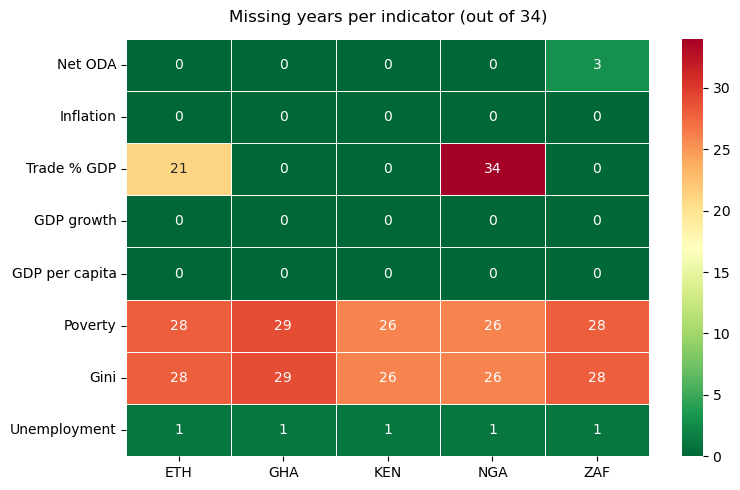

In [3]:
# pivot missing counts into a matrix: rows=indicators, cols=countries
missing = df_full.isnull().sum(axis=1).unstack(level=0)

# shorter names for the plot
missing.index = [
    "Net ODA", "Inflation", "Trade % GDP", "GDP growth",
    "GDP per capita", "Poverty", "Gini", "Unemployment"
]
missing.columns = ["ETH", "GHA", "KEN", "NGA", "ZAF"]

fig, ax = plt.subplots(figsize=(8, 5))

sns.heatmap(
    missing,
    annot=True,
    fmt="d",
    cmap="RdYlGn_r",
    linewidths=0.5,
    linecolor="white",
    vmin=0,
    vmax=34,
    ax=ax
)

ax.set_title("Missing years per indicator (out of 34)", pad=12)
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "coverage.png", dpi=150, bbox_inches="tight")
plt.show()

In [4]:
# poverty survey years by country
print("Poverty headcount ($2.15/day) — survey years available:\n")
for country in COUNTRIES:
    vals = df_full.loc[(country, "SI.POV.DDAY")].dropna()
    years = [y.replace("YR", "") for y in vals.index]
    print(f"  {LABELS[country]:15s} ({len(years)} points): {', '.join(years)}")

Poverty headcount ($2.15/day) — survey years available:

  Nigeria         (8 points): 1992, 1996, 2003, 2010, 2012, 2015, 2018, 2022
  Ghana           (5 points): 1991, 1998, 2005, 2012, 2016
  Kenya           (8 points): 1992, 1994, 1997, 2005, 2015, 2020, 2021, 2022
  South Africa    (6 points): 1993, 2000, 2005, 2008, 2010, 2014
  Ethiopia        (6 points): 1995, 1999, 2004, 2010, 2015, 2021


### What the coverage audit tells us

The data splits cleanly into two tiers:

**Tier 1 : Clean annual data (0–3 missing years):** GDP per capita, GDP growth, inflation,
Net ODA, and unemployment. These are the indicators that will carry the quantitative
modelling panel regressions, structural break tests, and time-series decomposition.

**Tier 2 : Sparse survey data (26–29 missing years):** Poverty and Gini. Each country has
only 5–8 observed survey points across 34 years. No single year has data for all five
countries simultaneously.

**Notable exclusions:**
- **Trade % GDP** drops out entirely for Nigeria (34 missing) and is thin for Ethiopia.
  It gets excluded from any model involving those two countries.
- **South Africa Net ODA** shows 3 missing years. From findings, South Africa is a middle-income country
  that stopped receiving significant ODA around 2012–2014, these are likely genuine
  zeroes rather than missing data. Worth verifying before imputing.

Poverty and Gini will be linearly interpolated within each
country's observed survey bounds (no extrapolation) for descriptive trend analysis and
correlation work. All regression results involving poverty will be run twice, once on
interpolated series, once on observed points only as a robustness check. This approach
follows the World Bank's own Poverty and Inequality Platform methodology for producing
regional aggregates between survey years.

---
## 3. Interpolation

We interpolate poverty and Gini now before any visualisation so that every chart from
this point forward can use the complete series. The method is simple linear interpolation
constrained to each country's first and last observed survey year. No values are invented
beyond the observed range.

To validate the approach, we plot Nigeria's poverty series with observed survey points
highlighted against the interpolated line. If the interpolation produces implausible
trajectories between survey points, we would see it here.

In [5]:
# interpolate poverty and gini within each country's observed range only
df_interp = df_full.copy()

pov_interp = (
    df_interp.xs("SI.POV.DDAY", level="series")
    .T
    .interpolate(method="linear", limit_area="inside")
    .T
)

gini_interp = (
    df_interp.xs("SI.POV.GINI", level="series")
    .T
    .interpolate(method="linear", limit_area="inside")
    .T
)

# verify: Nigeria poverty should have values from 1992 to 2022
print("Nigeria poverty — interpolated series:\n")
print(pov_interp.loc["NGA"].dropna().to_string())

Nigeria poverty — interpolated series:

YR1992    55.200000
YR1993    56.625000
YR1994    58.050000
YR1995    59.475000
YR1996    60.900000
YR1997    59.500000
YR1998    58.100000
YR1999    56.700000
YR2000    55.300000
YR2001    53.900000
YR2002    52.500000
YR2003    51.100000
YR2004    49.300000
YR2005    47.500000
YR2006    45.700000
YR2007    43.900000
YR2008    42.100000
YR2009    40.300000
YR2010    38.500000
YR2011    37.950000
YR2012    37.400000
YR2013    36.866667
YR2014    36.333333
YR2015    35.800000
YR2016    35.266667
YR2017    34.733333
YR2018    34.200000
YR2019    36.100000
YR2020    38.000000
YR2021    39.900000
YR2022    41.800000


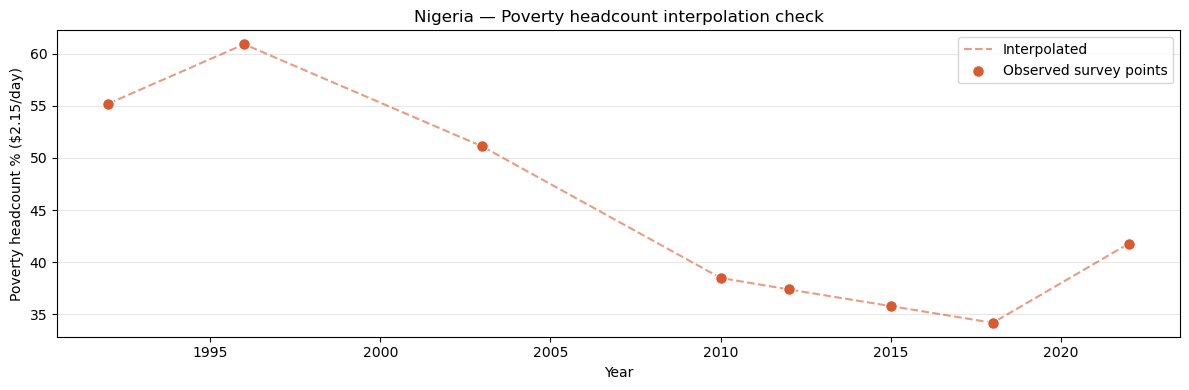

In [6]:
# validation plot: Nigeria poverty — observed vs interpolated
nga_pov_full = pov_interp.loc["NGA"]
nga_pov_full.index = nga_pov_full.index.str.replace("YR", "").astype(int)

obs_raw = df_full.loc[("NGA", "SI.POV.DDAY")].dropna()
obs_idx = obs_raw.index.str.replace("YR", "").astype(int)
obs_vals = obs_raw.values

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(nga_pov_full.index, nga_pov_full.values, color="#D85A30",
        linewidth=1.5, linestyle="--", alpha=0.6, label="Interpolated")
ax.scatter(obs_idx, obs_vals, color="#D85A30", s=70, zorder=5,
           edgecolors="white", linewidth=0.8, label="Observed survey points")
ax.set_title("Nigeria — Poverty headcount interpolation check")
ax.set_xlabel("Year")
ax.set_ylabel("Poverty headcount % ($2.15/day)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "nga_interpolation_check.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpolation check - Nigeria poverty series

The raw poverty headcount has 8 observed survey points between 1992 and 2022.
Linear interpolation fills the gaps within that range only.

Key observations from the interpolated series:

- **1992–1996**: Poverty rises from 55.2% to 60.9%, worsening during the post-SAP
  adjustment period.
- **1996–2018**: Consistent decline from 60.9% to 34.2% over 22 years, roughly 1.2
  percentage points per year on average.
- **2018–2022**: Sharp reversal, poverty jumps from 34.2% back to 41.8%, a 7.6pp
  increase in 4 years, erasing roughly a decade of progress.
- **The GDP-poverty lag**: GDP per capita peaked in 2015 and collapsed through
  2016–2017, yet poverty continued falling until 2018. The ~3-year lag suggests
  welfare outcomes do not respond immediately to growth shocks, a finding worth
  testing formally with lagged regressions.

The interpolation produces a plausible trajectory, no sudden jumps or implausible
reversals between survey points. We proceed with this approach for all countries,
with the robustness commitment to re-run regressions on observed points only.

---
## 4. Nigeria Deep Dive : GDP vs Poverty

Before comparing all five countries, we ground the analysis in one case. Nigeria is the
natural anchor. It is the largest economy in the panel, has the most poverty survey points
(8), and its growth-poverty relationship is the most nuanced. If we understand Nigeria
well, we have the visual vocabulary to read the other four countries.

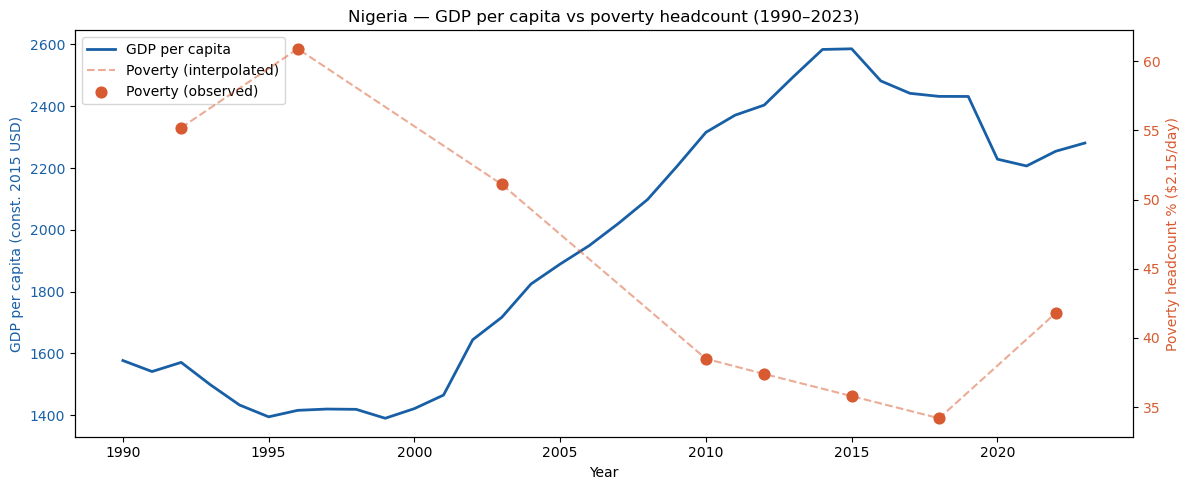

In [7]:
nga_gdp = df_full.loc[("NGA", "NY.GDP.PCAP.KD")].T
nga_pov_full = pov_interp.loc["NGA"]

nga_gdp.index = nga_gdp.index.str.replace("YR", "").astype(int)
nga_pov_full.index = nga_pov_full.index.str.replace("YR", "").astype(int)

observed_idx = df_full.loc[("NGA", "SI.POV.DDAY")].dropna().index
observed_idx = observed_idx.str.replace("YR", "").astype(int)
observed_vals = nga_pov_full.loc[observed_idx]

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(nga_gdp.index, nga_gdp.values, color="#185FA5", linewidth=2, label="GDP per capita")
ax1.set_ylabel("GDP per capita (const. 2015 USD)", color="#185FA5")
ax1.tick_params(axis="y", labelcolor="#185FA5")

ax2 = ax1.twinx()
ax2.plot(nga_pov_full.index, nga_pov_full.values, color="#D85A30", linewidth=1.5,
         linestyle="--", alpha=0.5, label="Poverty (interpolated)")
ax2.scatter(observed_idx, observed_vals.values, color="#D85A30", s=60, zorder=5,
            label="Poverty (observed)")
ax2.set_ylabel("Poverty headcount % ($2.15/day)", color="#D85A30")
ax2.tick_params(axis="y", labelcolor="#D85A30")

ax1.set_title("Nigeria — GDP per capita vs poverty headcount (1990–2023)")
ax1.set_xlabel("Year")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "nga_gdp_poverty.png", dpi=150, bbox_inches="tight")
plt.show()

### Nigeria - What the chart reveals

**The X-shape crossing (~2005–2006):** GDP per capita and poverty headcount cross around
2005. Before that point GDP was low and poverty was high. After it, GDP rises sharply
while poverty falls, the oil boom years finally start transmitting to welfare outcomes,
though slowly.

**Weak transmission during the boom (2000–2015):** GDP nearly doubled from ~$1,450 to
~$2,600 yet poverty only fell from ~55% to ~36%. A doubling of income per capita
reducing poverty by 19 percentage points is modest, it suggests growth was concentrated
rather than broad-based.

**The lag after the 2015 peak:** GDP peaked in 2015 and fell sharply through 2016–2017
(oil crash + recession). Poverty kept falling to its lowest point of 34.2% in 2018,
roughly 3 years after GDP peaked. This lag is the most analytically interesting feature
in the chart and will be tested formally with lagged regressions in the modelling notebook.

**The 2022 reversal:** Poverty jumps from 34.2% (2018) to 41.8% (2022), a 7.6pp increase.
GDP also dips in this period but does not fall as sharply, suggesting the poverty worsening
has drivers beyond just GDP contraction. Inflation, FX depreciation, and subsidy removal
are all candidates.

---
## 5. Cross-Country GDP vs Poverty

Now we apply the same lens across all five countries. The question is not just "does growth
reduce poverty?" every development textbook says it should. The question is **how much**
and **how reliably** growth translates to poverty reduction in each country. The differences
are where the analytical value lies.

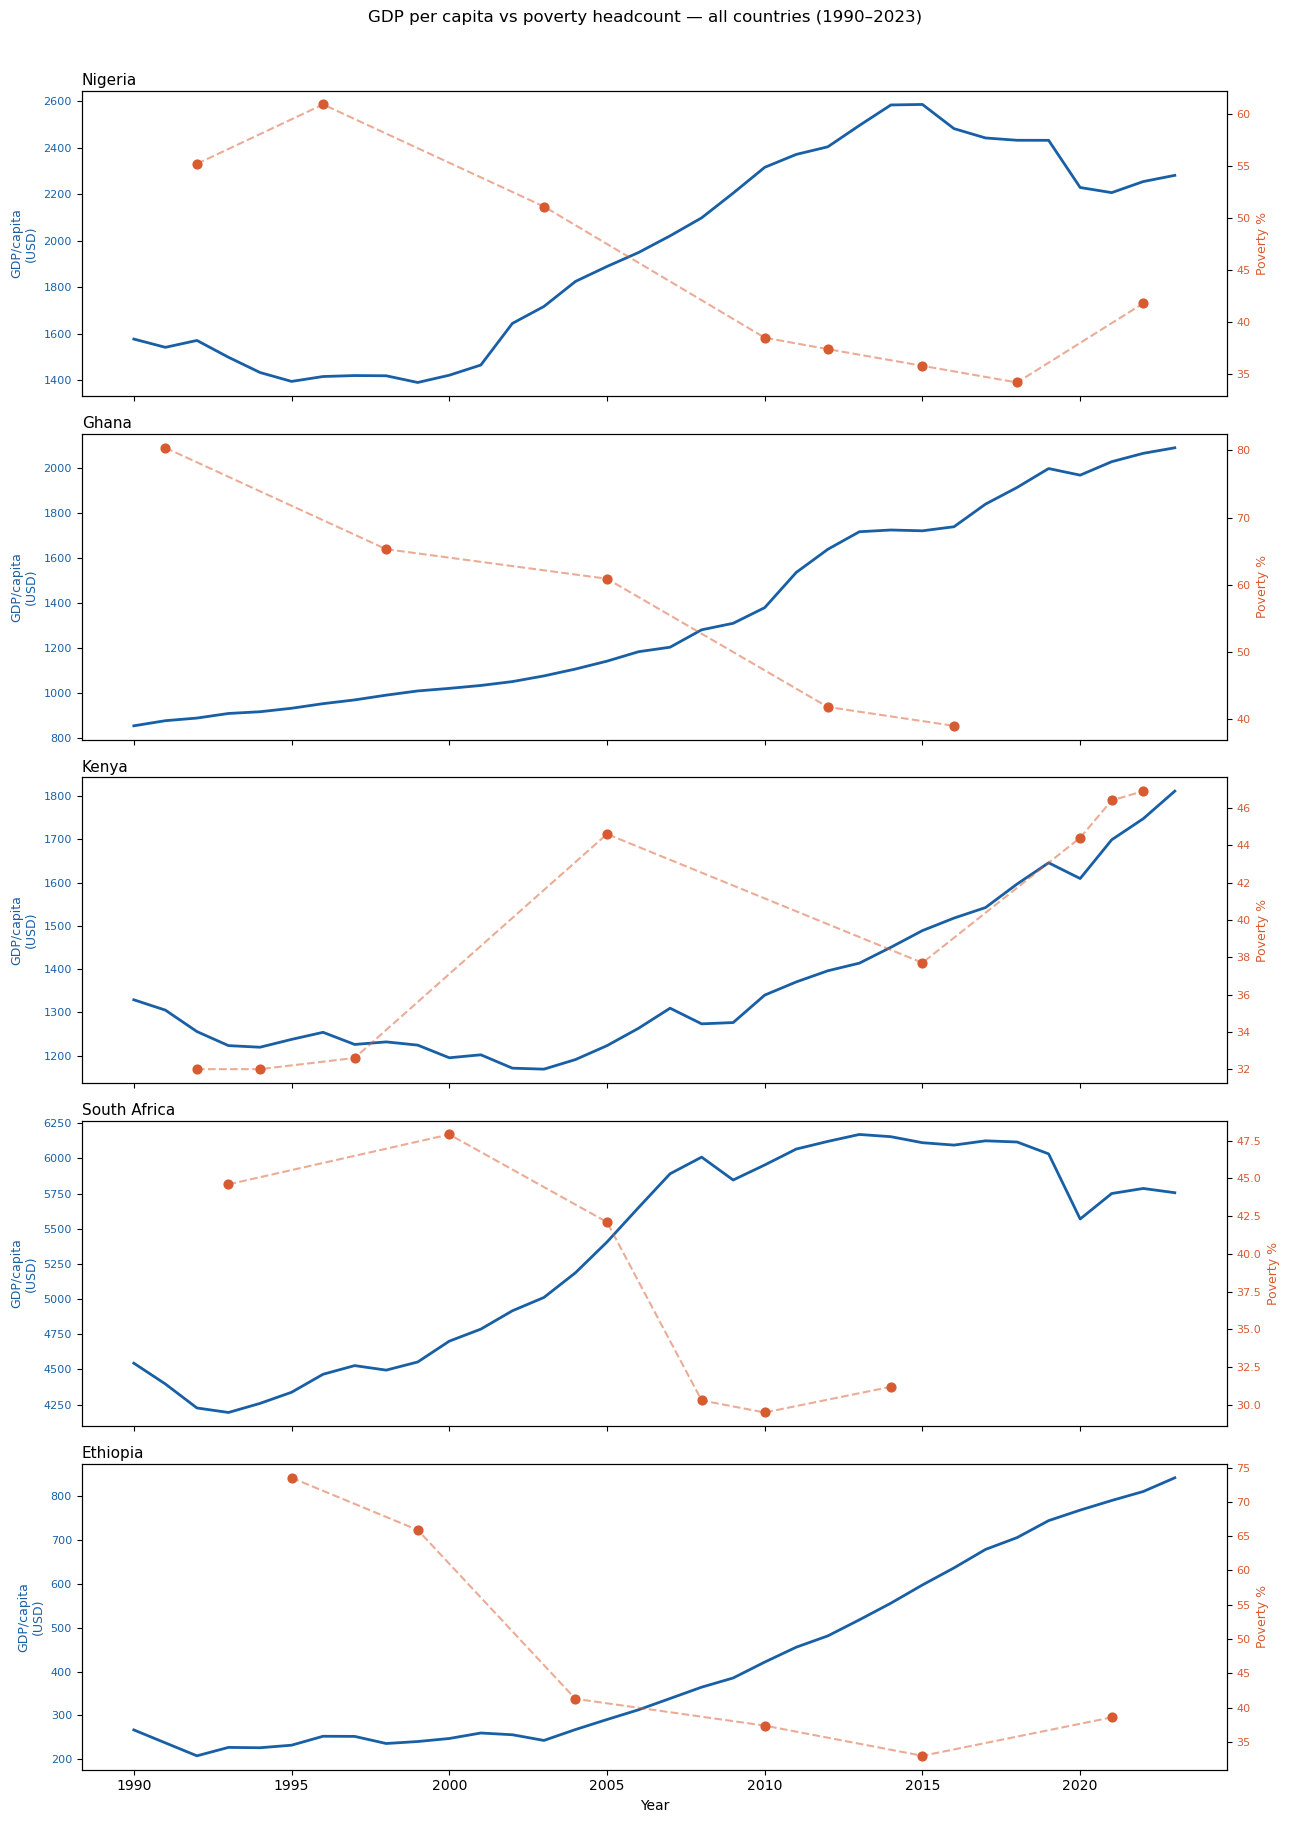

In [8]:
COLORS = {"gdp": "#185FA5", "pov": "#D85A30"}

fig, axes = plt.subplots(5, 1, figsize=(13, 18), sharex=True)

for ax, country in zip(axes, COUNTRIES):
    gdp = df_full.loc[(country, "NY.GDP.PCAP.KD")].T
    gdp.index = gdp.index.str.replace("YR", "").astype(int)

    pov_full = pov_interp.loc[country]
    pov_full.index = pov_full.index.str.replace("YR", "").astype(int)

    obs_idx = df_full.loc[(country, "SI.POV.DDAY")].dropna().index
    obs_idx = obs_idx.str.replace("YR", "").astype(int)
    obs_vals = pov_full.loc[obs_idx.intersection(pov_full.index)]

    ax2 = ax.twinx()

    ax.plot(gdp.index, gdp.values, color=COLORS["gdp"], linewidth=2)
    ax.set_ylabel("GDP/capita\n(USD)", color=COLORS["gdp"], fontsize=9)
    ax.tick_params(axis="y", labelcolor=COLORS["gdp"], labelsize=8)

    ax2.plot(pov_full.index, pov_full.values, color=COLORS["pov"],
             linewidth=1.5, linestyle="--", alpha=0.5)
    ax2.scatter(obs_idx, obs_vals.values, color=COLORS["pov"], s=40, zorder=5)
    ax2.set_ylabel("Poverty %", color=COLORS["pov"], fontsize=9)
    ax2.tick_params(axis="y", labelcolor=COLORS["pov"], labelsize=8)

    ax.set_title(LABELS[country], fontsize=11, loc="left", pad=4)

axes[-1].set_xlabel("Year")
fig.suptitle("GDP per capita vs poverty headcount — all countries (1990–2023)",
             fontsize=12, y=1.01)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "all_countries_gdp_poverty.png", dpi=150, bbox_inches="tight")
plt.show()

### Five countries, five different growth-poverty stories

**Nigeria:** Weak transmission. GDP more than doubled between 2000 and 2015 but poverty
only fell ~19pp. Growth was real but not broadly shared. The 2022 reversal is the
sharpest deterioration in the panel.

**Ghana:** The clearest pro-poor growth story in the panel. GDP grew steadily from ~$800
to ~$2,000 and poverty fell from ~80% to ~40% over the same period  -  a near 1-to-1
improvement relative to the scale of growth. The relationship is smooth and consistent
with no visible reversal.

**Kenya:** The outlier. Poverty was already low (~32%) in the early 1990s but rose through
the late 1990s and 2000s while GDP stayed flat  -  a period of growth-less poverty increase,
possibly driven by inequality or political instability (the 2007–2008 post-election
violence falls in this window). GDP picks up from 2010 onwards but poverty also rises
post-2015, reaching ~47% by 2022. Kenya is the only country in the panel where poverty
is *higher* at the end of the series than at the start. This is the most puzzling case
and warrants deeper investigation in the modelling phase  -  measurement changes in the
survey methodology, urbanisation effects, and regional inequality are all possible
explanations.

**South Africa:** Highest GDP in the panel by far (~$4,500–6,000) yet poverty sits at
30–47% throughout. A sharp drop in poverty around 2000–2008 coincides with post-apartheid
social spending expansion, not just growth. This decoupling between income level and
poverty makes South Africa the most analytically distinct country in the group.

**Ethiopia:** The most dramatic poverty reduction story. GDP grew from ~$200 to ~$850  - 
a 4x increase  -  while poverty fell from ~75% to ~35%, a 40pp drop. The relationship is
almost linear and suggests highly pro-poor growth, consistent with Ethiopia's state-led
agricultural development model in the 2000s–2010s.

**The key comparative question:** Nigeria had the highest absolute GDP among the lower-income
group yet the weakest poverty reduction relative to its growth rate. Ghana and Ethiopia,
with lower starting GDPs, achieved far more pro-poor outcomes. Is Nigerian growth
structurally less pro-poor than its peers? The panel model will test this formally.

---
## 6. The Inequality Lens  -  GDP vs Gini

The previous section asked whether growth reduced poverty. This section asks a sharper
question: **did growth reduce inequality?** A country can lower its poverty headcount
simply by raising average income, even if the rich capture most of the gains. The Gini
coefficient tells us whether the distribution itself is changing.

If a country shows falling poverty *and* falling Gini alongside GDP growth, that is
genuinely inclusive growth. If poverty falls but Gini stays flat or rises, growth is
lifting the floor without compressing the distribution  -  a weaker form of progress.

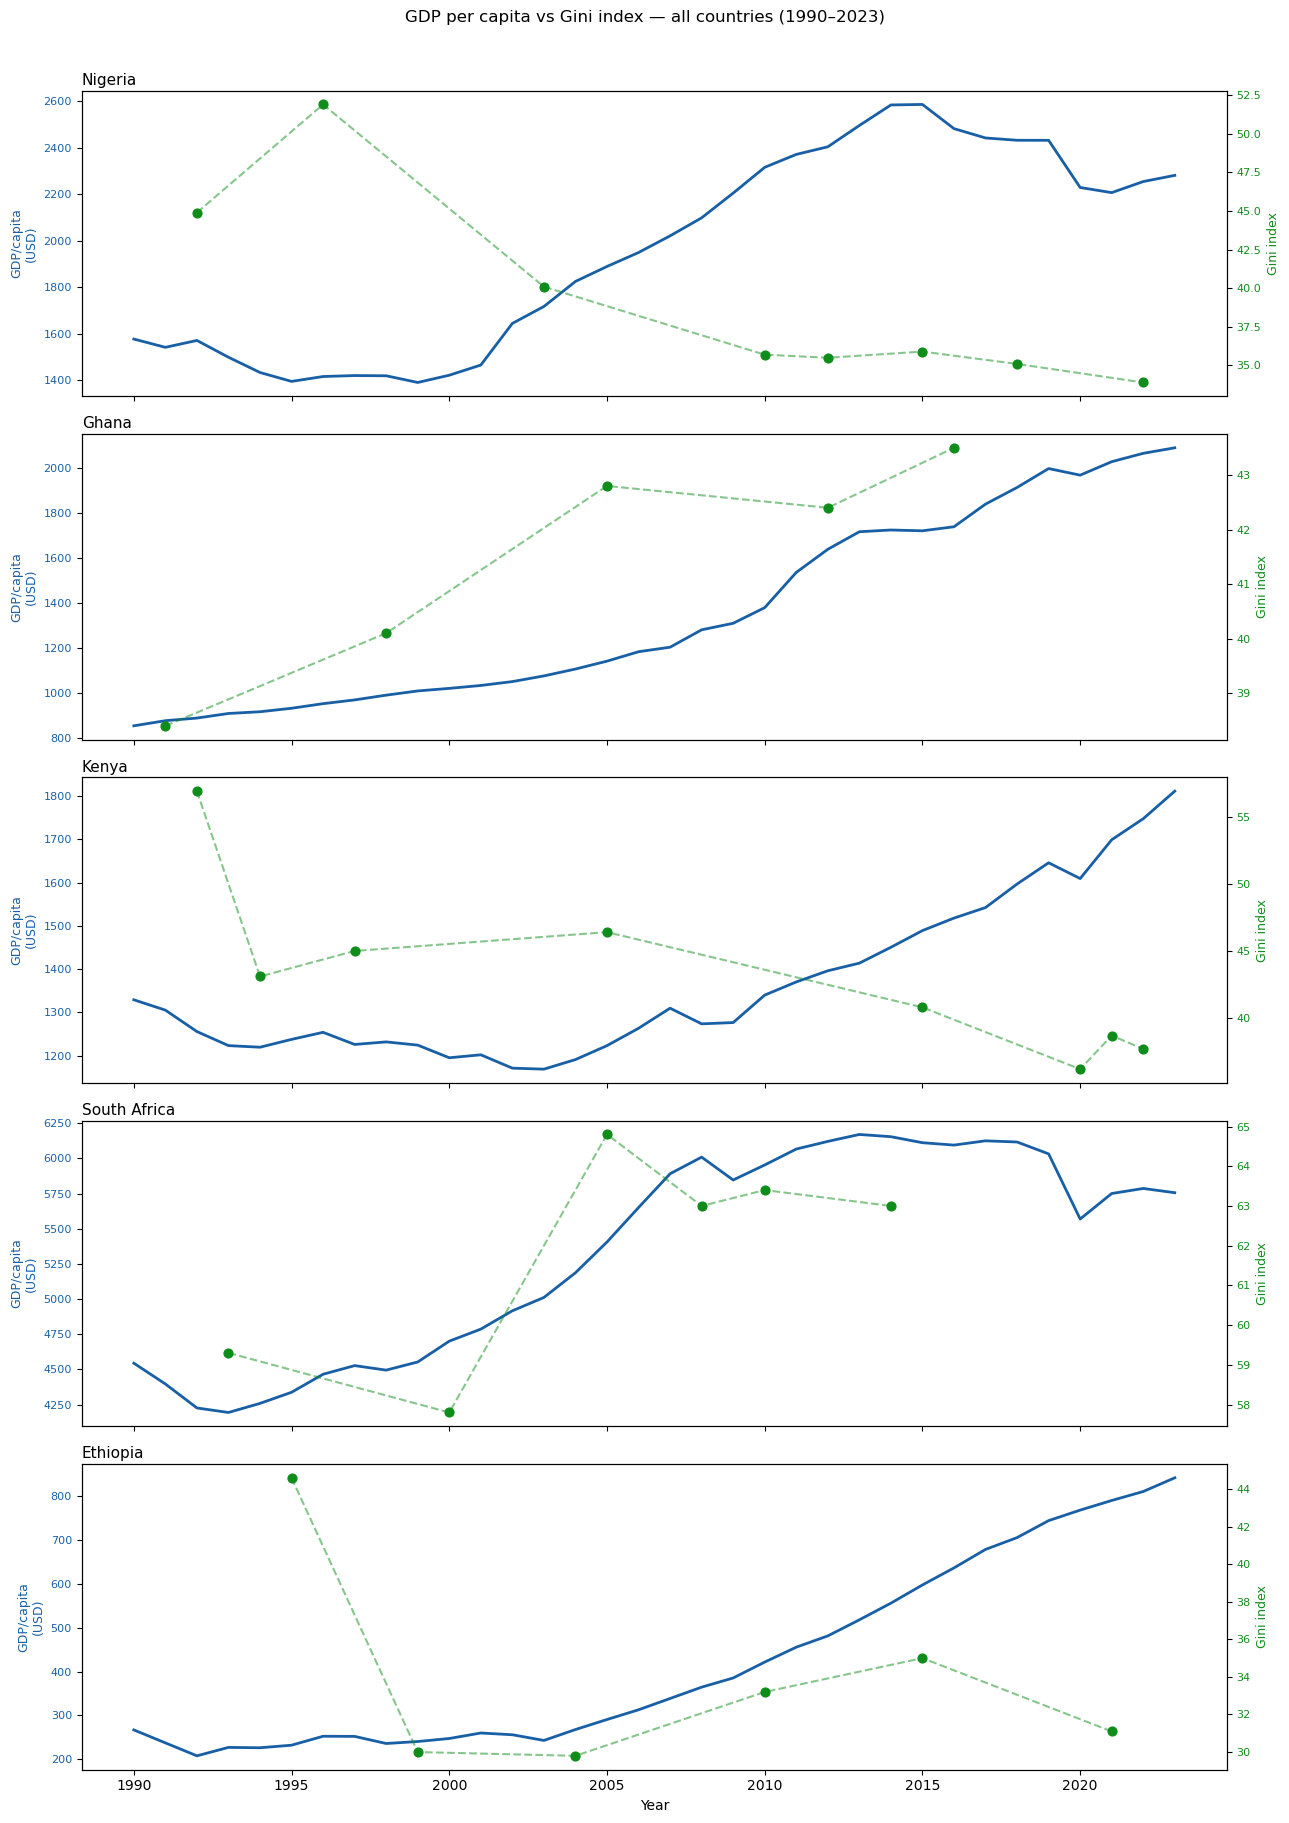

In [12]:
fig, axes = plt.subplots(5, 1, figsize=(13, 18), sharex=True)

COLORS_GINI = {"gdp": "#185FA5", "gini": "#0F8D1A"}

for ax, country in zip(axes, COUNTRIES):
    gdp = df_full.loc[(country, "NY.GDP.PCAP.KD")].T
    gdp.index = gdp.index.str.replace("YR", "").astype(int)

    gini_full = gini_interp.loc[country]
    gini_full.index = gini_full.index.str.replace("YR", "").astype(int)

    obs_idx = df_full.loc[(country, "SI.POV.GINI")].dropna().index
    obs_idx = obs_idx.str.replace("YR", "").astype(int)
    obs_vals = gini_full.loc[obs_idx.intersection(gini_full.index)]

    ax2 = ax.twinx()

    ax.plot(gdp.index, gdp.values, color=COLORS_GINI["gdp"], linewidth=2)
    ax.set_ylabel("GDP/capita\n(USD)", color=COLORS_GINI["gdp"], fontsize=9)
    ax.tick_params(axis="y", labelcolor=COLORS_GINI["gdp"], labelsize=8)

    ax2.plot(gini_full.index, gini_full.values, color=COLORS_GINI["gini"],
             linewidth=1.5, linestyle="--", alpha=0.5)
    ax2.scatter(obs_idx, obs_vals.values, color=COLORS_GINI["gini"], s=40, zorder=5)
    ax2.set_ylabel("Gini index", color=COLORS_GINI["gini"], fontsize=9)
    ax2.tick_params(axis="y", labelcolor=COLORS_GINI["gini"], labelsize=8)

    ax.set_title(LABELS[country], fontsize=11, loc="left", pad=4)

axes[-1].set_xlabel("Year")
fig.suptitle("GDP per capita vs Gini index — all countries (1990–2023)",
             fontsize=12, y=1.01)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "all_countries_gdp_gini.png", dpi=150, bbox_inches="tight")
plt.show()

### What the Gini lens adds

**Nigeria:** The most dramatic Gini compression in the panel  -  from 51.9 (1996) to 33.9
(2022). This is surprising given the weak poverty transmission we saw earlier. It suggests
that inequality *did* fall substantially, but from a high base, and the reduction in
inequality did not translate proportionally into poverty reduction. One explanation:
the compression happened in the middle of the distribution (narrowing the gap between
lower-middle and upper-middle income groups) rather than at the bottom tail where the
poverty line sits.

**Ghana:** Gini *rises* slightly from 38.4 to 43.5 even as poverty falls sharply. This
means Ghana's poverty reduction was driven primarily by overall income growth lifting
the floor, not by redistribution. Growth was pro-poor in outcome but not in distribution.

**Kenya:** Gini falls from a very high 56.9 (1992) to 37.7 (2022)  -  a major compression.
Yet poverty *rose* over the same period. This is the opposite of what we would expect:
falling inequality with rising poverty implies that average incomes fell or stagnated
while the distribution compressed. Kenya's puzzle deepens.

**South Africa:** Gini stays stubbornly high  -  59.3 to 63.0. The most unequal country
in the panel barely moved its distribution over two decades despite significant GDP
growth. The poverty reduction seen in Section 5 was almost entirely through social
transfers, not structural change. This is the clearest case of a country where growth
and inequality are decoupled.

**Ethiopia:** Gini fluctuates in a narrow band (30–44) while poverty falls dramatically.
Like Ghana, poverty reduction was growth-driven rather than redistribution-driven, but
Ethiopia started from a more equal base, so the floor-lifting effect reached the poor
more effectively.

**Key takeaway for modelling:** The Gini trends show that poverty reduction and inequality
reduction are *not the same thing* in this panel. Nigeria reduced inequality but not
poverty effectively. Ghana reduced poverty but not inequality. South Africa reduced
neither. This means any model that uses only GDP to explain poverty is missing a
critical channel  -  the Gini needs to enter the specification as a mediating variable.

---
## 7. GDP Growth Rates & Volatility

GDP per capita is a level  -  it tells us how rich a country is. GDP *growth rate* tells us
how fast it is getting richer (or poorer). For poverty reduction, both matter: a country
needs sustained growth, not just a high level. And volatility matters too  -  if growth
swings wildly, the poor are typically the most exposed to the downturns.

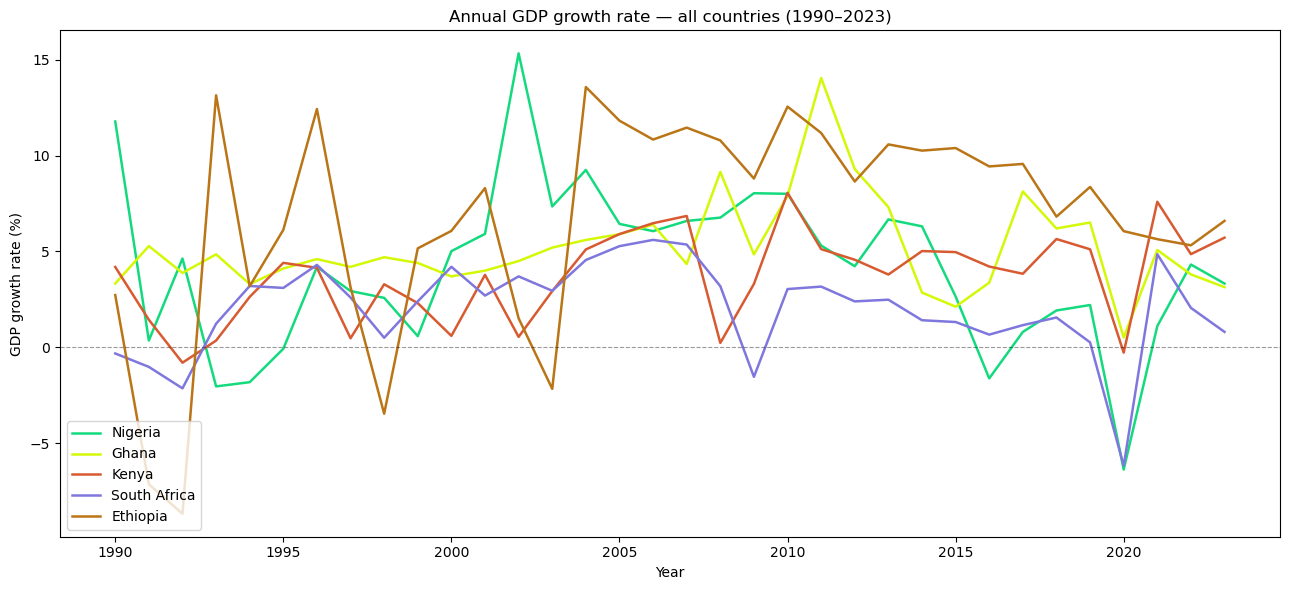

In [13]:
COUNTRY_COLORS = {
    "NGA": "#14DA7E", "GHA": "#D4F806",
    "KEN": "#D85A30", "ZAF": "#7F77DD", "ETH": "#BA7517"
}

fig, ax = plt.subplots(figsize=(13, 6))

for country in COUNTRIES:
    growth = df_full.loc[(country, "NY.GDP.MKTP.KD.ZG")].T
    growth.index = growth.index.str.replace("YR", "").astype(int)
    ax.plot(growth.index, growth.values, linewidth=1.8,
            label=LABELS[country], color=COUNTRY_COLORS[country])

ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.4)
ax.set_title("Annual GDP growth rate — all countries (1990–2023)")
ax.set_xlabel("Year")
ax.set_ylabel("GDP growth rate (%)")
ax.legend(loc="lower left")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "gdp_growth_all.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
# growth volatility summary
print("GDP Growth Volatility (1990–2023)\n")
print(f"{'Country':<18s} {'Mean':>8s} {'Std':>8s} {'CV':>8s} {'Min':>8s} {'Max':>8s}")
print("-" * 58)

for country in COUNTRIES:
    g = df_full.loc[(country, "NY.GDP.MKTP.KD.ZG")].T.dropna()
    mean = g.mean()
    std = g.std()
    cv = std / abs(mean) if mean != 0 else float('inf')
    print(f"{LABELS[country]:<18s} {mean:>7.1f}% {std:>7.1f}% {cv:>7.2f} {g.min():>7.1f}% {g.max():>7.1f}%")

GDP Growth Volatility (1990–2023)

Country                Mean      Std       CV      Min      Max
----------------------------------------------------------
Nigeria                4.1%     4.2%    1.03    -6.4%    15.3%
Ghana                  5.2%     2.5%    0.47     0.5%    14.0%
Kenya                  3.7%     2.3%    0.62    -0.8%     8.1%
South Africa           2.0%     2.4%    1.19    -6.2%     5.6%
Ethiopia               6.7%     5.5%    0.82    -8.7%    13.6%


### Growth patterns and volatility

**Nigeria:** The most volatile series in the panel. Two clear negative episodes  -  the
early 1990s contraction and the sharp crash in 2020 (COVID). The 2016 recession is also
visible as growth dips below zero. High peaks in 2002–2004 (~15%) correspond to the
post-debt-relief oil boom. Volatility is driven by oil price dependence  -  the series
swings harder than peers in both directions.

**Ghana:** Steady positive growth throughout, rarely dipping below zero. The 2011 spike
(~14%) marks the year oil production began at Jubilee Field. One of the most consistent
performers in the panel.

**Kenya:** Moderate and relatively stable. The 2008 dip corresponds to post-election
violence. Otherwise tracks in the 3–6% range with COVID as the only major negative shock.

**South Africa:** The flattest and weakest series. Growth rarely exceeds 5% and the
post-2010 slowdown is clear  -  growth trends toward zero well before COVID hits. This
matches South Africa's well-documented structural stagnation.

**Ethiopia:** The standout performer in the 2000s–2010s. Sustained growth of 8–13% for
over a decade is exceptional and explains the dramatic poverty reduction seen earlier.
The series becomes less extreme post-2018, consistent with political instability and
the Tigray conflict.

**Volatility and poverty:** The coefficient of variation (CV) quantifies what the chart
shows visually. If volatility itself is a poverty driver  -  not just the level of growth  - 
then we may want to include a rolling volatility measure in the panel model. The contrast
between Ghana (low CV, strong poverty reduction) and Nigeria (high CV, weak poverty
reduction) is suggestive but needs formal testing.

---
## 8. ODA (Aid) Flows

Official Development Assistance is a potential confound in the growth-poverty relationship.
If a country receives large aid inflows that are channelled into social spending, poverty
may fall independently of GDP growth. Conversely, aid-dependent countries may have growth
that is less "organic" and therefore less sustainable. We need to see the ODA series to
understand whether it belongs in the model as a control variable.

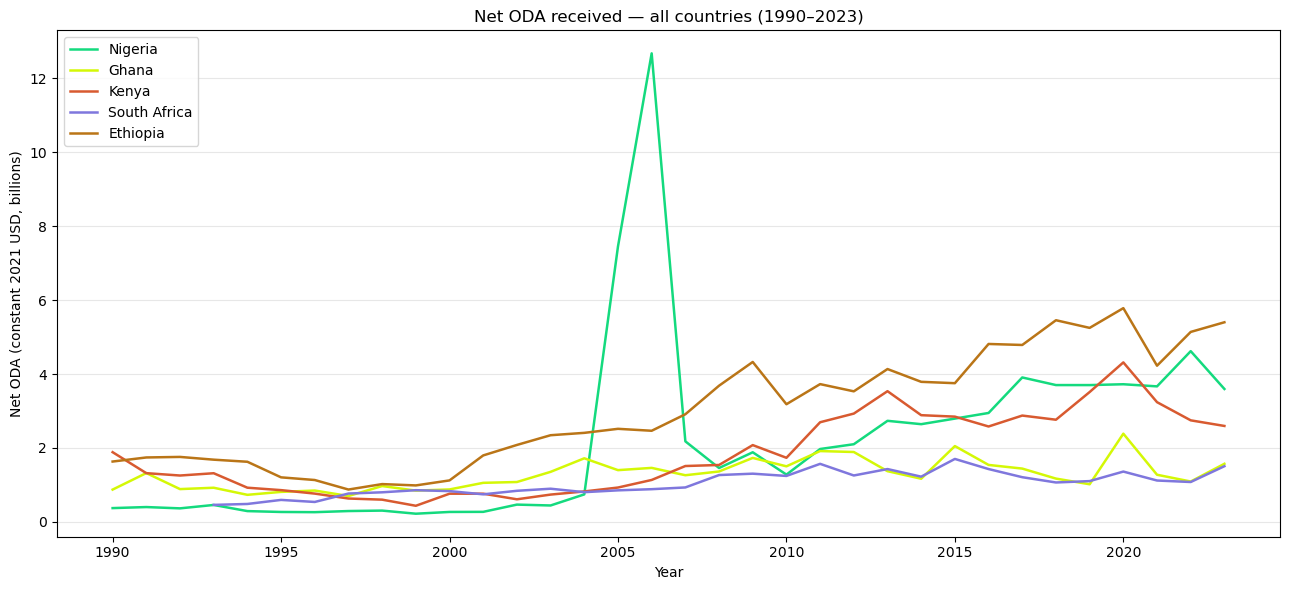

In [15]:
fig, ax = plt.subplots(figsize=(13, 6))

for country in COUNTRIES:
    oda = df_full.loc[(country, "DT.ODA.ALLD.KD")].T
    oda.index = oda.index.str.replace("YR", "").astype(int)
    # convert to billions for readability
    ax.plot(oda.index, oda.values / 1e9, linewidth=1.8,
            label=LABELS[country], color=COUNTRY_COLORS[country])

ax.set_title("Net ODA received — all countries (1990–2023)")
ax.set_xlabel("Year")
ax.set_ylabel("Net ODA (constant 2021 USD, billions)")
ax.legend(loc="upper left")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "oda_all_countries.png", dpi=150, bbox_inches="tight")
plt.show()

### ODA patterns

**Nigeria's Paris Club spike:** The single most visible feature is Nigeria's ~$12.7B ODA
spike in 2005–2006, corresponding to the Paris Club debt relief deal. This is not
traditional aid  -  it is a one-off accounting entry where forgiven debt is recorded as
ODA. If used as-is in a regression, this single observation could dominate the coefficient.
It will need to be either windsorised, dummied out, or the model should be run with and
without these years.

**Ethiopia's aid dependency:** Ethiopia consistently receives the most ODA relative to its
income level (~$3B mean on a $422 GDP per capita base). The upward trend through the
2000s coincides with Ethiopia's poverty reduction miracle  -  the modelling phase needs to
disentangle whether Ethiopia's poverty reduction was growth-driven, aid-driven, or both.

**South Africa's exit:** ODA to South Africa is negligible and trends toward zero  -  consistent
with its middle-income status. This confirms that South Africa's poverty story is entirely
domestic (social grants, not foreign aid).

**Ghana and Kenya:** Moderate aid recipients with relatively stable flows. No obvious
anomalies that would distort a regression.

---
## 9. Correlation Structure

Before building a regression model, we need to understand which variables move together.
A correlation matrix across the macro indicators reveals potential multicollinearity
(variables that are so correlated they cannot be separated in a regression) and hints
at which control variables add independent information versus which are redundant.

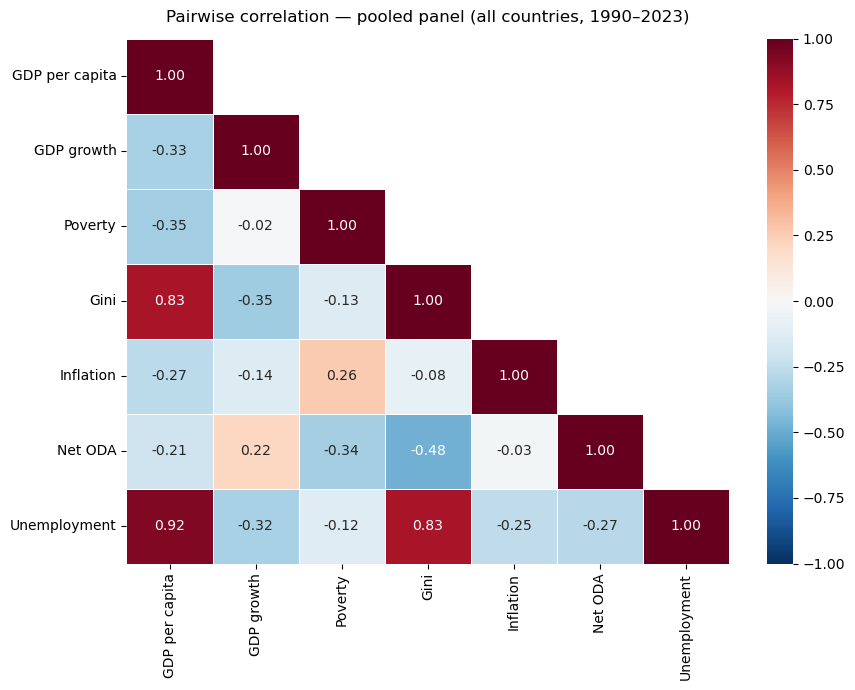

In [16]:
# build a long-format panel dataframe for correlation analysis
indicator_names = {
    "NY.GDP.PCAP.KD": "GDP per capita",
    "NY.GDP.MKTP.KD.ZG": "GDP growth",
    "SI.POV.DDAY": "Poverty",
    "SI.POV.GINI": "Gini",
    "FP.CPI.TOTL.ZG": "Inflation",
    "DT.ODA.ALLD.KD": "Net ODA",
    "SL.UEM.TOTL.ZS": "Unemployment",
}

# use interpolated poverty and gini for a fuller correlation picture
corr_frames = []
for country in COUNTRIES:
    rows = {}
    for code, name in indicator_names.items():
        if code == "SI.POV.DDAY":
            series = pov_interp.loc[country]
        elif code == "SI.POV.GINI":
            series = gini_interp.loc[country]
        else:
            series = df_full.loc[(country, code)]
        series.index = series.index.str.replace("YR", "").astype(int)
        rows[name] = series
    corr_frames.append(pd.DataFrame(rows))

panel_corr = pd.concat(corr_frames, ignore_index=True)

corr_matrix = panel_corr.corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor="white",
    ax=ax
)

ax.set_title("Pairwise correlation — pooled panel (all countries, 1990–2023)", pad=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

### What the correlations tell us

**GDP per capita and Unemployment (r = 0.92):** The strongest correlation in the panel
and almost certainly a composition artefact. The richest country (South Africa) also
has by far the highest unemployment. This is not a causal relationship - it reflects
South Africa's structural labour market problem. Country fixed effects will absorb this.

**GDP per capita and Gini (r = 0.83):** Richer countries in this panel tend to have
higher inequality. Again largely a South Africa effect. Without fixed effects this would
bias any inequality regression badly.

**Net ODA and Gini (r = -0.48):** Higher aid flows are associated with lower inequality.
Plausible if aid is channelled into social spending, but could also reflect that poorer,
more equal countries receive more aid. Direction of causality is unclear and needs
careful model specification.

**GDP per capita and Poverty (r = -0.35):** Weaker than expected. Higher income weakly
predicts lower poverty at the pooled panel level, but the relationship is noisy - which
is consistent with the cross-country visual analysis showing countries like South Africa
breaking the pattern entirely.

**Inflation and Poverty (r = 0.26):** Mild positive correlation - higher inflation
associated with higher poverty. Consistent with the hypothesis that inflation is an
independent poverty driver, particularly for Nigeria's 2022 reversal. Warrants inclusion
as a regressor.

**No severe multicollinearity among the regressors:** The pairs we plan to use together
- GDP per capita, inflation, ODA, Gini - show moderate correlations at most. The
modelling notebook will confirm this with VIF scores, but nothing here raises a red flag.

---
## 10. Descriptive Statistics

With the visual exploration complete, we now summarise the raw numbers. These tables
confirm what we have seen in the charts and provide reference values for the modelling
phase  -  means to centre around, standard deviations to normalise by, and extremes to
watch for as potential outliers.

In [17]:
indicators = {
    "DT.ODA.ALLD.KD": "Net ODA",
    "FP.CPI.TOTL.ZG": "Inflation",
    "NY.GDP.MKTP.KD.ZG": "GDP growth",
    "NY.GDP.PCAP.KD": "GDP per capita",
    "SI.POV.DDAY": "Poverty",
    "SI.POV.GINI": "Gini",
    "SL.UEM.TOTL.ZS": "Unemployment",
}

def fmt_value(val, indicator):
    if indicator == "Net ODA":
        return f"${val/1e9:.2f}B"
    elif indicator == "GDP per capita":
        return f"${val:,.0f}"
    elif indicator in ["GDP growth", "Inflation", "Unemployment", "Poverty"]:
        return f"{val:.1f}%"
    else:
        return f"{val:.1f}"

rows = []
for code, name in indicators.items():
    for country in COUNTRIES:
        s = df_full.loc[(country, code)].T.dropna()
        rows.append({
            "Indicator": name,
            "Country": LABELS[country],
            "N": len(s),
            "Mean": fmt_value(s.mean(), name),
            "Std": fmt_value(s.std(), name),
            "Min": fmt_value(s.min(), name),
            "Max": fmt_value(s.max(), name),
        })

desc = pd.DataFrame(rows)

for ind in desc["Indicator"].unique():
    subset = desc[desc["Indicator"] == ind].drop(columns="Indicator")
    print(f"\n{'='*55}")
    print(f"  {ind}")
    print(f"{'='*55}")
    print(subset.to_string(index=False))


  Net ODA
     Country  N   Mean    Std    Min     Max
     Nigeria 34 $2.19B $2.53B $0.22B $12.68B
       Ghana 34 $1.28B $0.41B $0.70B  $2.39B
       Kenya 34 $1.83B $1.08B $0.44B  $4.32B
South Africa 31 $1.04B $0.33B $0.46B  $1.70B
    Ethiopia 34 $3.01B $1.53B $0.87B  $5.78B

  Inflation
     Country  N  Mean   Std   Min   Max
     Nigeria 34 18.3% 15.9%  5.4% 72.8%
       Ghana 34 20.3% 13.2%  4.9% 59.5%
       Kenya 34 11.2%  9.1%  1.6% 46.0%
South Africa 34  6.6%  3.3% -0.7% 15.3%
    Ethiopia 34 12.5% 12.3% -8.5% 44.4%

  GDP growth
     Country  N Mean  Std   Min   Max
     Nigeria 34 4.1% 4.2% -6.4% 15.3%
       Ghana 34 5.2% 2.5%  0.5% 14.0%
       Kenya 34 3.7% 2.3% -0.8%  8.1%
South Africa 34 2.0% 2.4% -6.2%  5.6%
    Ethiopia 34 6.7% 5.5% -8.7% 13.6%

  GDP per capita
     Country  N   Mean  Std    Min    Max
     Nigeria 34 $1,953 $430 $1,390 $2,586
       Ghana 34 $1,357 $422   $856 $2,092
       Kenya 34 $1,365 $181 $1,169 $1,811
South Africa 34 $5,330 $728 $4,194 $6,

### Descriptive statistics  -  key observations

**GDP per capita:** South Africa ($5,330 mean) is in a completely different income bracket
from the rest of the panel. Ethiopia ($422) is at the other extreme. Country fixed effects
in the panel model are essential  -  without them, South Africa's income level would dominate
any pooled regression.

**GDP growth:** Ethiopia leads on average growth (6.7%) but also has the highest volatility
(std 5.5%) and the deepest single-year contraction (-8.7%). Nigeria's 15.3% peak is the
highest in the panel  -  the 2002 post-debt-relief oil boom. Ghana is the most consistent
grower, never contracting in the full 34-year period.

**Poverty:** Ghana has the highest mean poverty (57.5%) but only 5 survey points, so the
average is sensitive to which years were surveyed. South Africa has the lowest mean (37.6%)
despite having the highest Gini  -  consistent with its large social transfer system
compressing the poverty headcount below what inequality alone would predict.

**Gini:** South Africa (mean 61.9) is the most unequal country in the panel by a wide
margin  -  nearly 20 points above Kenya (43.1) which is second. Ethiopia (33.9) is the most
equal. This range gives the panel model enough variation to detect inequality drivers.

**Inflation:** Nigeria (18.3% mean, 72.8% max) and Ghana (20.3%) are high-inflation
economies. The 72.8% Nigeria peak is 2023, driven by naira depreciation and subsidy
removal. South Africa (6.6%) is the most price-stable. Inflation will be log-transformed
before entering any regression to reduce the influence of extreme values.

**Unemployment:** South Africa (24.8%) is a structural outlier  -  roughly 6x every other
country in the panel. This is not measurement noise, it reflects a genuine structural
feature. Its influence on panel coefficients will be checked explicitly.

**Net ODA:** Nigeria's mean of $2.19B is inflated by the 2005–2006 Paris Club debt relief,
which shows up as a ~$12.7B spike  -  the largest single ODA observation in the panel.
Ethiopia receives the most aid relative to its income level ($3.01B mean on a $422 GDP
per capita base), consistent with its aid-dependent growth model.

---
## 11. Summary & Bridge to Modelling

### What the EDA revealed

The central finding is that **GDP growth is necessary but not sufficient for poverty
reduction**  -  and the strength of the transmission varies dramatically across countries.
Ghana and Ethiopia show strong, near-linear growth-poverty relationships. Nigeria shows
weak transmission despite significant growth. South Africa shows poverty reduction driven
by social policy rather than growth. Kenya shows the most puzzling pattern  -  rising
poverty despite moderate growth and falling inequality.

The Gini analysis adds a critical dimension: **poverty reduction and inequality reduction
are not the same thing.** Nigeria compressed its Gini substantially but failed to reduce
poverty proportionally. Ghana reduced poverty without reducing inequality. These divergent
paths mean any model that uses only GDP to explain poverty is underspecified.

### Questions the EDA raised

1. **The GDP-poverty lag:** Nigeria's poverty continued falling for ~3 years after GDP
   peaked. Is this a real lag in welfare transmission, or an artefact of interpolation
   between survey points? Lagged regression models will test this.

2. **Kenya's anomaly:** Poverty rose while GDP grew and inequality fell. Is this a
   measurement artefact (survey methodology changes), a regional composition effect
   (urban gains masked by rural deterioration), or a genuine failure of growth
   transmission?

3. **The role of inflation:** Nigeria's 2022 poverty reversal coincides with extreme
   inflation (72.8% by 2023). If inflation is an independent poverty driver beyond GDP,
   it needs to enter the model as a separate regressor.

4. **Aid vs growth as poverty drivers:** Ethiopia's poverty reduction coincides with
   both high growth and high ODA. Disentangling these requires a model that controls
   for both simultaneously.

5. **Structural breaks:** Nigeria's GDP shows clear break points  -  the oil boom, the
   2016 recession, the 2020 crash. Ethiopia's growth deceleration post-2018 is visible.
   South Africa's post-2010 stagnation is unmistakable. Formal break detection (Bai-Perron,
   CUSUM) will identify these precisely.

### What the modelling notebook will test

- **Panel fixed-effects regression** of poverty on GDP per capita, Gini, inflation, and
  ODA  -  with country fixed effects to absorb structural differences.
- **Growth-poverty elasticity** estimated per country  -  how many percentage points of
  poverty reduction does a 1% increase in GDP buy in each country?
- **Lagged models** to test whether GDP shocks take 1–3 years to transmit to poverty.
- **Structural break detection** on GDP growth series  -  where did growth regimes change,
  and did poverty outcomes change at the same points?
- **Robustness checks** on all poverty regressions using observed-only survey points
  versus the interpolated series.